# NaturaViT + ALO: Improved Hybrid CNN-ViT with Ant Lion Optimization

## Healthy / Unhealthy Sleep Classification

### Pipeline
1. **Hybrid CNN-ViT** trained end-to-end on sleep signal features (baseline)
2. **Deep feature extraction** from trained CNN-ViT (256-dim pooling output)
3. **ALO (Ant Lion Optimization)** selects most discriminative deep features
4. **SVM, KNN, MLP** classifiers trained on ALO-selected features
5. **Comparison** of baseline vs ALO-improved results

### Dataset
- `healthy_unhealthy1.csv` — 18,599 samples, 1025 features, binary labels (0=Healthy, 1=Unhealthy)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report,
    cohen_kappa_score, roc_auc_score
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from time import time

import warnings
warnings.filterwarnings('ignore')

os.makedirs('artifacts', exist_ok=True)

print(f"TensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow: 2.20.0
NumPy: 2.4.1
GPU Available: False


In [2]:
# Load dataset
data = pd.read_csv('../healthy_unhealthy1.csv')
print(f"Dataset shape: {data.shape}")

# Separate features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values.astype(int)

print(f"Features: {X.shape}, Labels: {y.shape}")
print(f"Class distribution: {np.bincount(y)}")

# Normalize features (z-score)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0) + 1e-8
X_normalized = (X - X_mean) / X_std

# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Train labels: {np.bincount(y_train)}")
print(f"Test labels:  {np.bincount(y_test)}")

Dataset shape: (18599, 1026)
Features: (18599, 1025), Labels: (18599,)
Class distribution: [9299 9300]

Train: (14879, 1025), Test: (3720, 1025)
Train labels: [7439 7440]
Test labels:  [1860 1860]


## Stage 1: Hybrid CNN-ViT Model (Baseline)

### Architecture
1. **Multi-Scale CNN** — Parallel Conv1D (kernel 3, 7, 15) for local feature extraction
2. **Positional Encoding** — Learnable embeddings for sequence position
3. **2x Transformer Blocks** — Multi-head self-attention for global context
4. **Dual Pooling** — GlobalAvgPool + GlobalMaxPool concatenated (256-dim deep features)
5. **Classification Head** — Dense(256) → Dense(128) → Dense(2, softmax)

In [3]:
class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads=8, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.projection_dim = embed_dim // num_heads
        self.query_dense = layers.Dense(embed_dim)
        self.key_dense = layers.Dense(embed_dim)
        self.value_dense = layers.Dense(embed_dim)
        self.combine_heads = layers.Dense(embed_dim)
        self.dropout = layers.Dropout(dropout)

    def get_config(self):
        config = super().get_config()
        config.update({'embed_dim': self.embed_dim, 'num_heads': self.num_heads})
        return config

    def attention(self, query, key, value):
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        weights = tf.nn.softmax(score / tf.math.sqrt(dim_key), axis=-1)
        weights = self.dropout(weights)
        return tf.matmul(weights, value), weights

    def separate_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs, training=False):
        batch_size = tf.shape(inputs)[0]
        query = self.separate_heads(self.query_dense(inputs), batch_size)
        key = self.separate_heads(self.key_dense(inputs), batch_size)
        value = self.separate_heads(self.value_dense(inputs), batch_size)
        attention, _ = self.attention(query, key, value)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))
        return self.combine_heads(concat_attention)


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout
        self.att = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim, 'num_heads': self.num_heads,
            'ff_dim': self.ff_dim, 'dropout': self.dropout_rate
        })
        return config

    def call(self, inputs, training=False):
        attn_output = self.dropout1(self.att(inputs, training=training), training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.dropout2(self.ffn(out1, training=training), training=training)
        return self.layernorm2(out1 + ffn_output)

print("Custom layers defined.")

Custom layers defined.


In [4]:
def create_hybrid_cnn_vit_model(input_shape, num_classes=2):
    inputs = layers.Input(shape=input_shape)
    x = layers.Reshape((input_shape[0], 1))(inputs)

    # Multi-scale CNN
    b1 = layers.BatchNormalization()(layers.Conv1D(32, 3, padding='same', activation='relu')(x))
    b2 = layers.BatchNormalization()(layers.Conv1D(32, 7, padding='same', activation='relu')(x))
    b3 = layers.BatchNormalization()(layers.Conv1D(32, 15, padding='same', activation='relu')(x))
    x = layers.Dropout(0.2)(layers.Concatenate()([b1, b2, b3]))

    x = layers.Dropout(0.2)(layers.MaxPooling1D(2)(layers.BatchNormalization()(
        layers.Conv1D(64, 5, padding='same', activation='relu')(x))))
    x = layers.Dropout(0.3)(layers.MaxPooling1D(2)(layers.BatchNormalization()(
        layers.Conv1D(128, 5, padding='same', activation='relu')(x))))

    # Positional encoding
    seq_len = input_shape[0] // 4
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_emb = layers.Embedding(input_dim=seq_len, output_dim=128)(positions)
    x = x + pos_emb

    # Transformer blocks
    x = TransformerBlock(embed_dim=128, num_heads=8, ff_dim=256, dropout=0.1)(x)
    x = TransformerBlock(embed_dim=128, num_heads=8, ff_dim=256, dropout=0.1)(x)

    # Dual pooling -> 256-dim deep features
    x_avg = layers.GlobalAveragePooling1D()(x)
    x_max = layers.GlobalMaxPooling1D()(x)
    deep_features = layers.Concatenate(name='deep_features')([x_avg, x_max])

    # Classification head
    x = layers.Dropout(0.4)(layers.BatchNormalization()(layers.Dense(256, activation='relu')(deep_features)))
    x = layers.Dropout(0.3)(layers.BatchNormalization()(layers.Dense(128, activation='relu')(x)))
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs=inputs, outputs=outputs, name='Hybrid_CNN_ViT')

print("Model builder ready.")

Model builder ready.


In [5]:
# Create model
input_shape = (X_train.shape[1],)
model = create_hybrid_cnn_vit_model(input_shape, num_classes=2)
model.summary()

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=25, verbose=1, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1, min_lr=1e-7),
    ModelCheckpoint('artifacts/hybrid_cnn_vit_alo_best.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

# Train
print("\nStarting training...")
start_time = time()

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

training_time = time() - start_time
print(f"\nTraining completed in {training_time:.2f}s ({training_time/60:.2f} min)")

Model: "Hybrid_CNN_ViT"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1025)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1025, 1)   │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1025, 32)  │        128 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1025, 32)  │        256 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1025, 32)  │        512 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1025, 32)  │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1025, 32)  │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1025, 32)  │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1025, 96)  │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1025, 96)  │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1025, 64)  │     30,784 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1025, 64)  │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 512, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512, 64)   │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 512, 128)  │     41,088 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 128)  │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 256, 128)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256, 128)  │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 128)  │          0 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block   │ (None, 256, 128)  │    132,480 │ add[0][0]       

 Total params: 439,362 (1.68 MB)

 Trainable params: 438,018 (1.67 MB)

 Non-trainable params: 1,344 (5.25 KB)

...


Epoch 51: finished saving model to artifacts/hybrid_cnn_vit_alo_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.8495 - loss: 0.3301 - val_accuracy: 0.8464 - val_loss: 0.3677 - learning_rate: 5.0000e-04
Epoch 52/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8463 - loss: 0.3385
Epoch 52: val_accuracy did not improve from 0.84644
186/186 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - accuracy: 0.8488 - loss: 0.3368 - val_accuracy: 0.8353 - val_loss: 0.3797 - learning_rate: 5.0000e-04
Epoch 53/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8510 - loss: 0.3322
Epoch 53: val_accuracy did not improve from 0.84644
186/186 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.8467 - loss: 0.3390 - val_accuracy: 0.7826 - val_loss: 0.4826 - learning_rate: 5.0000e-04
Epoch 54/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8475 - loss: 0.3378
Epoch 54: val_accuracy did not improve from 0.84644
186/186 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.8475 - loss: 0.3


Epoch 58: finished saving model to artifacts/hybrid_cnn_vit_alo_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.8521 - loss: 0.3239 - val_accuracy: 0.8485 - val_loss: 0.3493 - learning_rate: 5.0000e-04
Epoch 59/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8598 - loss: 0.3142
Epoch 59: val_accuracy did not improve from 0.84845
186/186 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.8601 - loss: 0.3155 - val_accuracy: 0.8427 - val_loss: 0.3607 - learning_rate: 5.0000e-04
Epoch 60/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8524 - loss: 0.3220
Epoch 60: val_accuracy improved from 0.84845 to 0.85316, saving model to artifacts/hybrid_cnn_vit_alo_best.h5



Epoch 60: finished saving model to artifacts/hybrid_cnn_vit_alo_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.8540 - loss: 0.3203 - val_accuracy: 0.8532 - val_loss: 0.3374 - learning_rate: 5.0000e-04
Epoch 61/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8632 - loss: 0.3084
Epoch 61: val_accuracy did not improve from 0.85316
186/186 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.8577 - loss: 0.3168 - val_accuracy: 0.8357 - val_loss: 0.3653 - learning_rate: 5.0000e-04
Epoch 62/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8615 - loss: 0.3127
Epoch 62: val_accuracy did not improve from 0.85316
186/186 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.8572 - loss: 0.3179 - val_accuracy: 0.8132 - val_loss: 0.4131 - learning_rate: 5.0000e-04
Epoch 63/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8642 - loss: 0.3152
Epoch 63: val_accuracy improved from 0.85316 to 0.86895, saving model to artifacts/hybrid_cnn_vit_alo_best.h5



Epoch 63: finished saving model to artifacts/hybrid_cnn_vit_alo_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.8638 - loss: 0.3102 - val_accuracy: 0.8690 - val_loss: 0.3138 - learning_rate: 5.0000e-04
Epoch 64/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8572 - loss: 0.3140
Epoch 64: val_accuracy did not improve from 0.86895
186/186 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.8568 - loss: 0.3162 - val_accuracy: 0.8306 - val_loss: 0.4124 - learning_rate: 5.0000e-04
Epoch 65/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8626 - loss: 0.3062
Epoch 65: val_accuracy did not improve from 0.86895
186/186 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.8663 - loss: 0.3013 - val_accuracy: 0.8555 - val_loss: 0.3340 - learning_rate: 5.0000e-04
Epoch 66/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8624 - loss: 0.3178
Epoch 66: val_accuracy did not improve from 0.86895
186/186 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.8588 - loss: 0.3


Epoch 89: finished saving model to artifacts/hybrid_cnn_vit_alo_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.8801 - loss: 0.2684 - val_accuracy: 0.8763 - val_loss: 0.2965 - learning_rate: 2.5000e-04
Epoch 90/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8818 - loss: 0.2612
Epoch 90: val_accuracy did not improve from 0.87634
186/186 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.8794 - loss: 0.2668 - val_accuracy: 0.8458 - val_loss: 0.3560 - learning_rate: 2.5000e-04
Epoch 91/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8788 - loss: 0.2745
Epoch 91: val_accuracy did not improve from 0.87634
186/186 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.8810 - loss: 0.2698 - val_accuracy: 0.8636 - val_loss: 0.3193 - learning_rate: 2.5000e-04
Epoch 92/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8813 - loss: 0.2654
Epoch 92: val_accuracy did not improve from 0.87634
186/186 ━━━━━━━━━━━━━━━━━━━━ 214s 1s/step - accuracy: 0.8818 - loss: 0.2

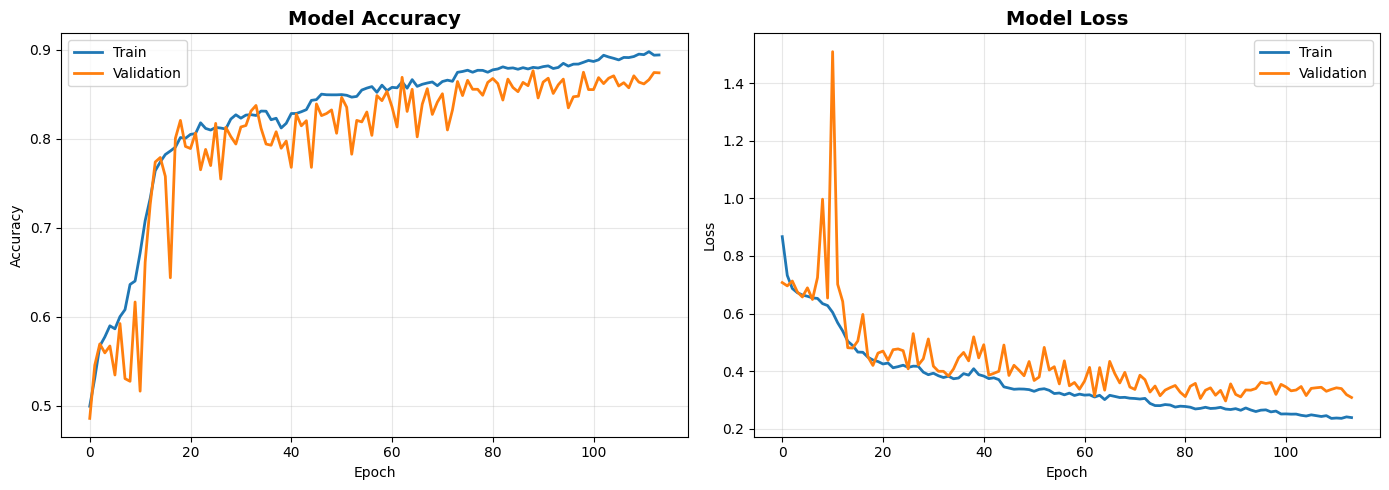

Final Train Accuracy: 89.41%
Final Val Accuracy:   87.40%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Final Train Accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Val Accuracy:   {history.history['val_accuracy'][-1]*100:.2f}%")

In [7]:
# Baseline CNN-ViT evaluation
y_pred_prob = model.predict(X_test, verbose=0)
y_pred_baseline = np.argmax(y_pred_prob, axis=1)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_prec = precision_score(y_test, y_pred_baseline)
baseline_rec = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)
baseline_auc = roc_auc_score(y_test, y_pred_prob[:, 1])
baseline_kappa = cohen_kappa_score(y_test, y_pred_baseline)

cm_base = confusion_matrix(y_test, y_pred_baseline)
tn, fp, fn, tp = cm_base.ravel()
baseline_spec = tn / (tn + fp)

print("=" * 60)
print("BASELINE HYBRID CNN-ViT - TEST RESULTS")
print("=" * 60)
print(f"Accuracy   : {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"Precision  : {baseline_prec:.4f}")
print(f"Recall     : {baseline_rec:.4f}")
print(f"Specificity: {baseline_spec:.4f}")
print(f"F1 Score   : {baseline_f1:.4f}")
print(f"AUC        : {baseline_auc:.4f}")
print(f"Kappa      : {baseline_kappa:.4f}")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline,
                            target_names=['Healthy', 'Unhealthy'], digits=4))

BASELINE HYBRID CNN-ViT - TEST RESULTS
Accuracy   : 0.8640 (86.40%)
Precision  : 0.8402
Recall     : 0.8989
Specificity: 0.8290
F1 Score   : 0.8686
AUC        : 0.9487
Kappa      : 0.7280

Classification Report:
              precision    recall  f1-score   support

     Healthy     0.8913    0.8290    0.8591      1860
   Unhealthy     0.8402    0.8989    0.8686      1860

    accuracy                         0.8640      3720
   macro avg     0.8658    0.8640    0.8638      3720
weighted avg     0.8658    0.8640    0.8638      3720



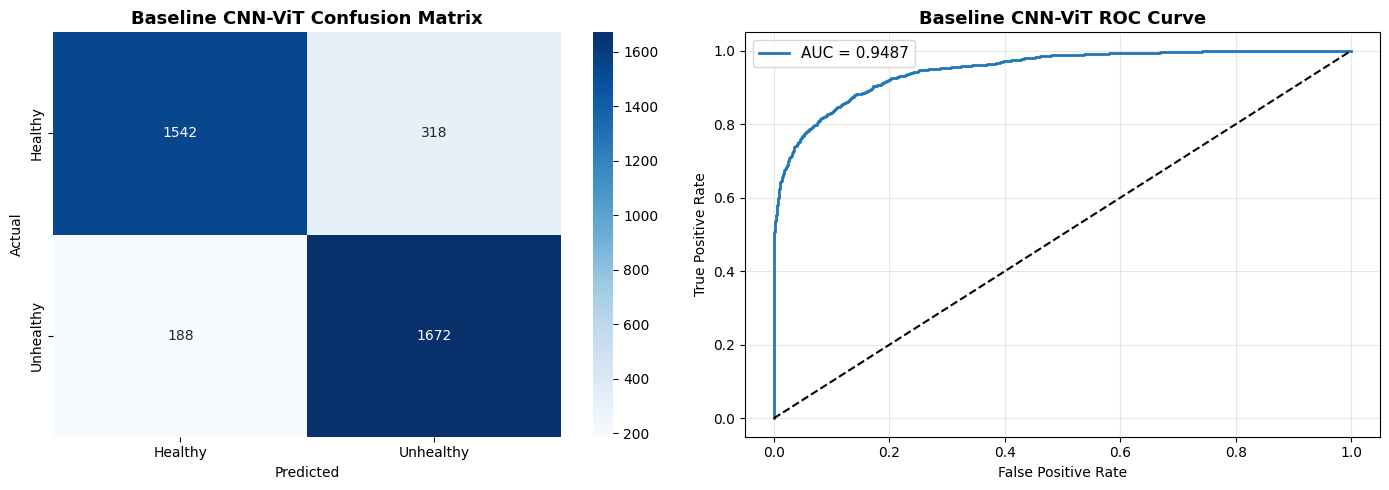

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Unhealthy'],
            yticklabels=['Healthy', 'Unhealthy'], ax=axes[0])
axes[0].set_title('Baseline CNN-ViT Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC curve
fpr_b, tpr_b, _ = roc_curve(y_test, y_pred_prob[:, 1])
roc_auc_b = auc(fpr_b, tpr_b)
axes[1].plot(fpr_b, tpr_b, linewidth=2, label=f'AUC = {roc_auc_b:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('Baseline CNN-ViT ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/baseline_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

## Stage 2: Deep Feature Extraction + ALO Feature Selection

### Approach
1. Extract **256-dimensional deep features** from the trained CNN-ViT (pooling layer output)
2. Apply **Ant Lion Optimization (ALO)** to select the most discriminative feature dimensions
3. Train **SVM, KNN, MLP** classifiers on ALO-selected deep features
4. ALO uses **3-fold stratified CV** with KNN on **training data only** (no data leakage)

In [9]:
# Create feature extractor from the trained model
feature_extractor = Model(
    inputs=model.input,
    outputs=model.get_layer('deep_features').output,
    name='Feature_Extractor'
)

# Extract deep features
train_deep = feature_extractor.predict(X_train, verbose=0)
test_deep = feature_extractor.predict(X_test, verbose=0)

print(f"Train deep features: {train_deep.shape}")
print(f"Test deep features : {test_deep.shape}")

# Scale deep features
deep_scaler = StandardScaler()
train_deep_scaled = deep_scaler.fit_transform(train_deep)
test_deep_scaled = deep_scaler.transform(test_deep)

print("\nDeep features extracted and scaled.")

Train deep features: (14879, 256)
Test deep features : (3720, 256)

Deep features extracted and scaled.


In [10]:
# =========================================================
# ANT LION OPTIMIZATION (ALO) - Feature Selection
# =========================================================

def initialization(n, dim, ub, lb):
    return np.random.rand(n, dim) * (ub - lb) + lb

def roulette_wheel_selection(weights):
    accumulation = np.cumsum(weights)
    p = np.random.rand() * accumulation[-1]
    return np.where(accumulation >= p)[0][0]

def random_walk(t, max_iter, lb, ub, dim):
    I = 1
    if t > max_iter * 0.95: I = 1e6
    elif t > max_iter * 0.9: I = 1e5
    elif t > max_iter * 0.75: I = 1e4
    elif t > max_iter * 0.5: I = 1e3
    elif t > max_iter * 0.1: I = 1e2

    lb_adj = lb / I
    ub_adj = ub / I

    Xrw = np.cumsum(2 * (np.random.rand(max_iter, dim) > 0.5) - 1, axis=0)
    a = Xrw.min(axis=0)
    b = Xrw.max(axis=0)
    return ((Xrw - a) * (ub_adj - lb_adj)) / (b - a + 1e-10) + lb_adj

def feature_selection_fobj(pos, X_data, y_data):
    mask = pos > 0.5
    if np.sum(mask) == 0:
        return 1.0

    X_sel = X_data[:, mask]
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    accs = []
    for tr, te in skf.split(X_sel, y_data):
        clf = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='minkowski')
        clf.fit(X_sel[tr], y_data[tr])
        accs.append(accuracy_score(y_data[te], clf.predict(X_sel[te])))

    alpha = 0.99
    return alpha * (1 - np.mean(accs)) + (1 - alpha) * (np.sum(mask) / len(mask))

def ALO(SearchAgents_no, Max_iter, lb, ub, dim, X_data, y_data):
    Antlions = initialization(SearchAgents_no, dim, ub, lb)
    Antlions_fit = np.array([feature_selection_fobj(al, X_data, y_data) for al in Antlions])

    elite_idx = np.argmin(Antlions_fit)
    Elite = Antlions[elite_idx].copy()
    Elite_fit = Antlions_fit[elite_idx]

    Ants = initialization(SearchAgents_no, dim, ub, lb)
    curve = np.zeros(Max_iter)

    for t in range(Max_iter):
        ants_fit = np.zeros(SearchAgents_no)

        for i in range(SearchAgents_no):
            idx = roulette_wheel_selection(1 / (Antlions_fit + 1e-10))
            RA = random_walk(t, Max_iter, lb, ub, dim)[t] + Antlions[idx]
            RE = random_walk(t, Max_iter, lb, ub, dim)[t] + Elite
            Ants[i] = np.clip((RA + RE) / 2, lb, ub)
            ants_fit[i] = feature_selection_fobj(Ants[i], X_data, y_data)

        merged = np.vstack((Antlions, Ants))
        merged_fit = np.hstack((Antlions_fit, ants_fit))
        order = np.argsort(merged_fit)
        Antlions = merged[order[:SearchAgents_no]]
        Antlions_fit = merged_fit[order[:SearchAgents_no]]

        if Antlions_fit[0] < Elite_fit:
            Elite_fit = Antlions_fit[0]
            Elite = Antlions[0].copy()

        curve[t] = Elite_fit
        print(f"Iter {t+1}/{Max_iter} | Best Fitness = {Elite_fit:.6f} | CV Acc = {1-Elite_fit:.4f}")

    return Elite_fit, Elite, curve


# Run ALO on deep features (training data only)
print("Running ALO Feature Selection on Deep Features...")
print(f"Feature dimension: {train_deep_scaled.shape[1]}\n")

np.random.seed(42)

best_score, best_pos, alo_curve = ALO(
    SearchAgents_no=20,
    Max_iter=25,
    lb=0, ub=1,
    dim=train_deep_scaled.shape[1],
    X_data=train_deep_scaled,
    y_data=y_train
)

best_mask = best_pos > 0.5

print(f"\nALO Completed!")
print(f"Selected Features: {np.sum(best_mask)} / {len(best_mask)}")
print(f"Best CV Accuracy : {1 - best_score:.4f}")
print(f"Feature Indices  : {np.where(best_mask)[0]}")

Running ALO Feature Selection on Deep Features...
Feature dimension: 256

Iter 1/25 | Best Fitness = 0.113432 | CV Acc = 0.8866
Iter 2/25 | Best Fitness = 0.113432 | CV Acc = 0.8866
Iter 3/25 | Best Fitness = 0.113432 | CV Acc = 0.8866
Iter 4/25 | Best Fitness = 0.112790 | CV Acc = 0.8872
Iter 5/25 | Best Fitness = 0.112790 | CV Acc = 0.8872
Iter 6/25 | Best Fitness = 0.112790 | CV Acc = 0.8872
Iter 7/25 | Best Fitness = 0.112790 | CV Acc = 0.8872
Iter 8/25 | Best Fitness = 0.112790 | CV Acc = 0.8872
Iter 9/25 | Best Fitness = 0.112790 | CV Acc = 0.8872
Iter 10/25 | Best Fitness = 0.112790 | CV Acc = 0.8872
Iter 11/25 | Best Fitness = 0.112790 | CV Acc = 0.8872
Iter 12/25 | Best Fitness = 0.112790 | CV Acc = 0.8872
Iter 13/25 | Best Fitness = 0.112790 | CV Acc = 0.8872
Iter 14/25 | Best Fitness = 0.112790 | CV Acc = 0.8872
Iter 15/25 | Best Fitness = 0.112790 | CV Acc = 0.8872
Iter 16/25 | Best Fitness = 0.112790 | CV Acc = 0.8872
Iter 17/25 | Best Fitness = 0.112790 | CV Acc = 0.8872


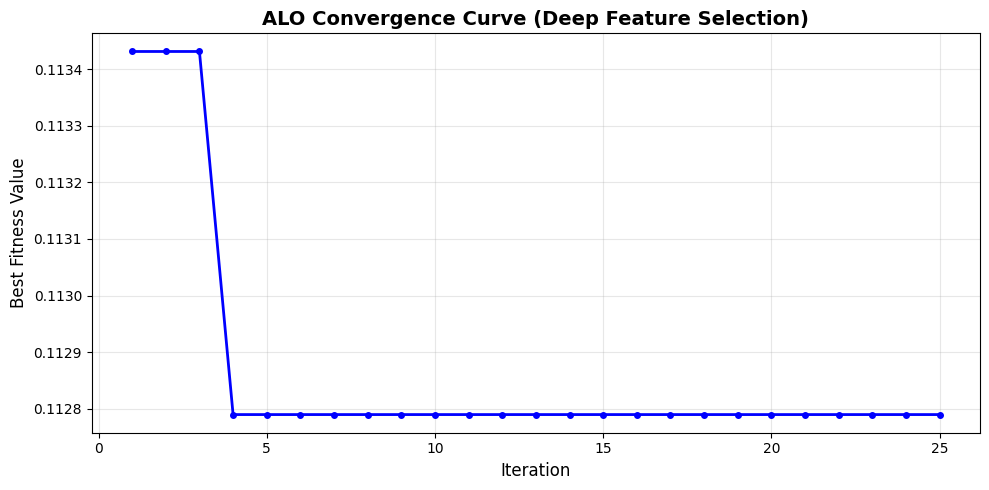

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(alo_curve)+1), alo_curve, 'b-o', linewidth=2, markersize=4)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Best Fitness Value", fontsize=12)
plt.title("ALO Convergence Curve (Deep Feature Selection)", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/alo_convergence.png', dpi=300, bbox_inches='tight')
plt.show()

## Stage 3: Classifier Evaluation on ALO-Selected Deep Features

Training SVM, KNN, and MLP on the ALO-selected feature subset.
Each classifier is evaluated with full metrics, confusion matrix, and ROC curve.

Train shape after ALO: (14879, 128)
Test shape after ALO : (3720, 128)

  SVM Performance (ALO-Selected Deep Features)
Accuracy   : 0.8766 (87.66%)
Precision  : 0.8960
Recall     : 0.8522
Specificity: 0.9011
F1 Score   : 0.8735
AUC        : 0.9368
Kappa      : 0.7532

Classification Report:
              precision    recall  f1-score   support

     Healthy     0.8590    0.9011    0.8796      1860
   Unhealthy     0.8960    0.8522    0.8735      1860

    accuracy                         0.8766      3720
   macro avg     0.8775    0.8766    0.8765      3720
weighted avg     0.8775    0.8766    0.8765      3720



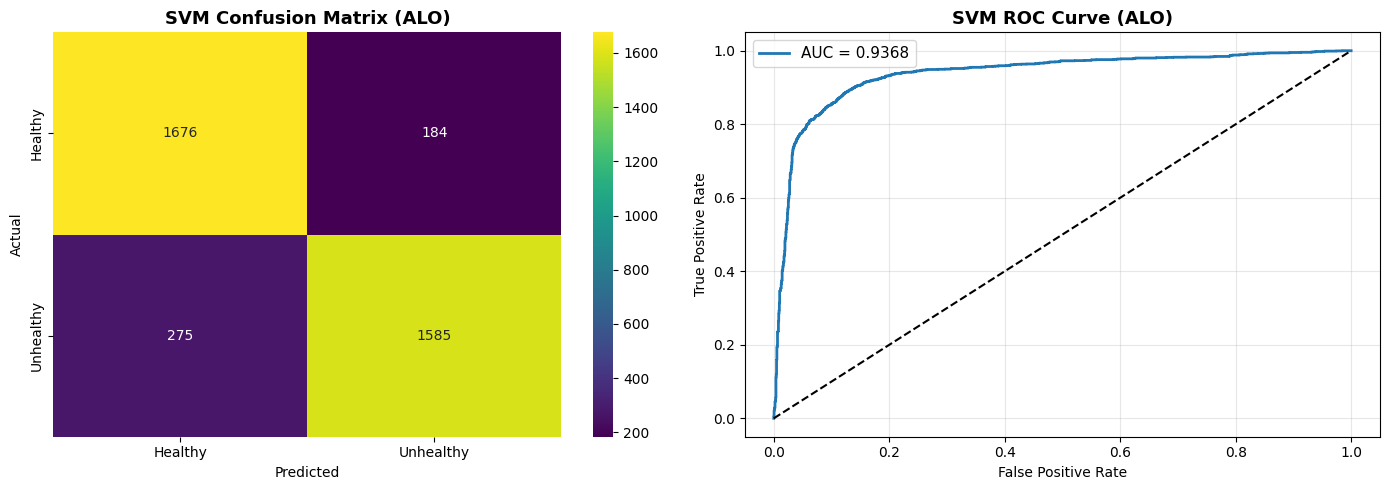


  KNN Performance (ALO-Selected Deep Features)
Accuracy   : 0.8720 (87.20%)
Precision  : 0.8794
Recall     : 0.8624
Specificity: 0.8817
F1 Score   : 0.8708
AUC        : 0.9339
Kappa      : 0.7441

Classification Report:
              precision    recall  f1-score   support

     Healthy     0.8650    0.8817    0.8733      1860
   Unhealthy     0.8794    0.8624    0.8708      1860

    accuracy                         0.8720      3720
   macro avg     0.8722    0.8720    0.8720      3720
weighted avg     0.8722    0.8720    0.8720      3720



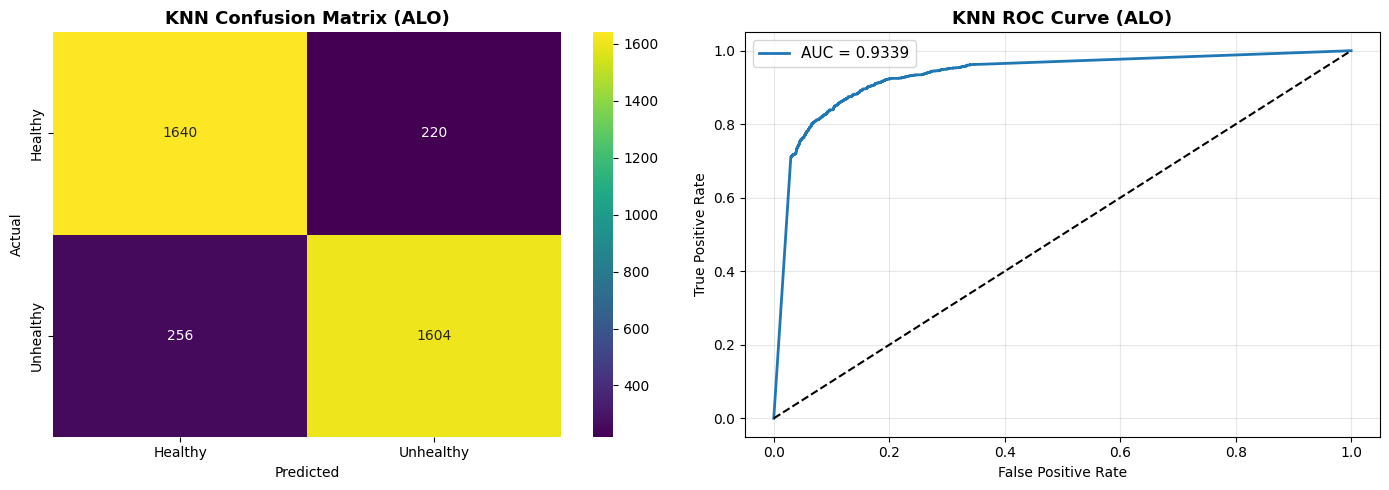


  MLP Performance (ALO-Selected Deep Features)
Accuracy   : 0.8645 (86.45%)
Precision  : 0.8826
Recall     : 0.8409
Specificity: 0.8882
F1 Score   : 0.8612
AUC        : 0.9409
Kappa      : 0.7290

Classification Report:
              precision    recall  f1-score   support

     Healthy     0.8480    0.8882    0.8676      1860
   Unhealthy     0.8826    0.8409    0.8612      1860

    accuracy                         0.8645      3720
   macro avg     0.8653    0.8645    0.8644      3720
weighted avg     0.8653    0.8645    0.8644      3720



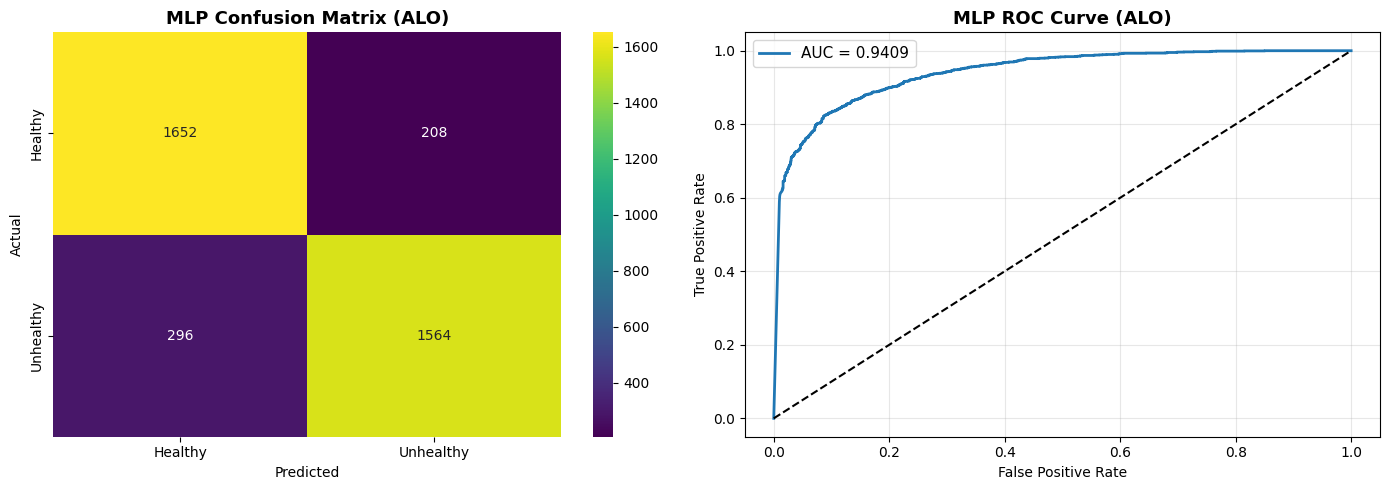


All classifiers evaluated!


In [12]:
# Apply ALO mask to deep features
X_train_alo = train_deep_scaled[:, best_mask]
X_test_alo = test_deep_scaled[:, best_mask]

print(f"Train shape after ALO: {X_train_alo.shape}")
print(f"Test shape after ALO : {X_test_alo.shape}")

# Define classifiers
classifiers = {
    "SVM": SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, weights='distance'),
    "MLP": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)
}

alo_results = {}

for name, clf in classifiers.items():

    print(f"\n{'='*60}")
    print(f"  {name} Performance (ALO-Selected Deep Features)")
    print(f"{'='*60}")

    clf.fit(X_train_alo, y_train)
    preds = clf.predict(X_test_alo)
    probs = clf.predict_proba(X_test_alo)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    spec_f1 = f1_score(y_test, preds)
    auc_val = roc_auc_score(y_test, probs[:, 1])
    kappa = cohen_kappa_score(y_test, preds)

    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)

    alo_results[name] = {
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'specificity': spec, 'f1': spec_f1, 'auc': auc_val,
        'kappa': kappa, 'cm': cm, 'probs': probs, 'preds': preds
    }

    print(f"Accuracy   : {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision  : {prec:.4f}")
    print(f"Recall     : {rec:.4f}")
    print(f"Specificity: {spec:.4f}")
    print(f"F1 Score   : {spec_f1:.4f}")
    print(f"AUC        : {auc_val:.4f}")
    print(f"Kappa      : {kappa:.4f}")

    print(f"\nClassification Report:")
    print(classification_report(y_test, preds,
                                target_names=['Healthy', 'Unhealthy'], digits=4))

    # Plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
                xticklabels=['Healthy', 'Unhealthy'],
                yticklabels=['Healthy', 'Unhealthy'], ax=axes[0])
    axes[0].set_title(f'{name} Confusion Matrix (ALO)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_test, probs[:, 1])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, linewidth=2, label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--')
    axes[1].set_title(f'{name} ROC Curve (ALO)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'artifacts/{name.lower()}_alo_evaluation.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\nAll classifiers evaluated!")


  FINAL COMPARISON: BASELINE vs ALO-IMPROVED
                    Model Accuracy Precision Recall Specificity F1-Score    AUC  Kappa
Hybrid CNN-ViT (Baseline)   86.40%    84.02% 89.89%      82.90%   86.86% 94.87% 0.7280
                ALO + SVM   87.66%    89.60% 85.22%      90.11%   87.35% 93.68% 0.7532
                ALO + KNN   87.20%    87.94% 86.24%      88.17%   87.08% 93.39% 0.7441
                ALO + MLP   86.45%    88.26% 84.09%      88.82%   86.12% 94.09% 0.7290

Best Model: ALO + SVM (Accuracy: 87.66%)


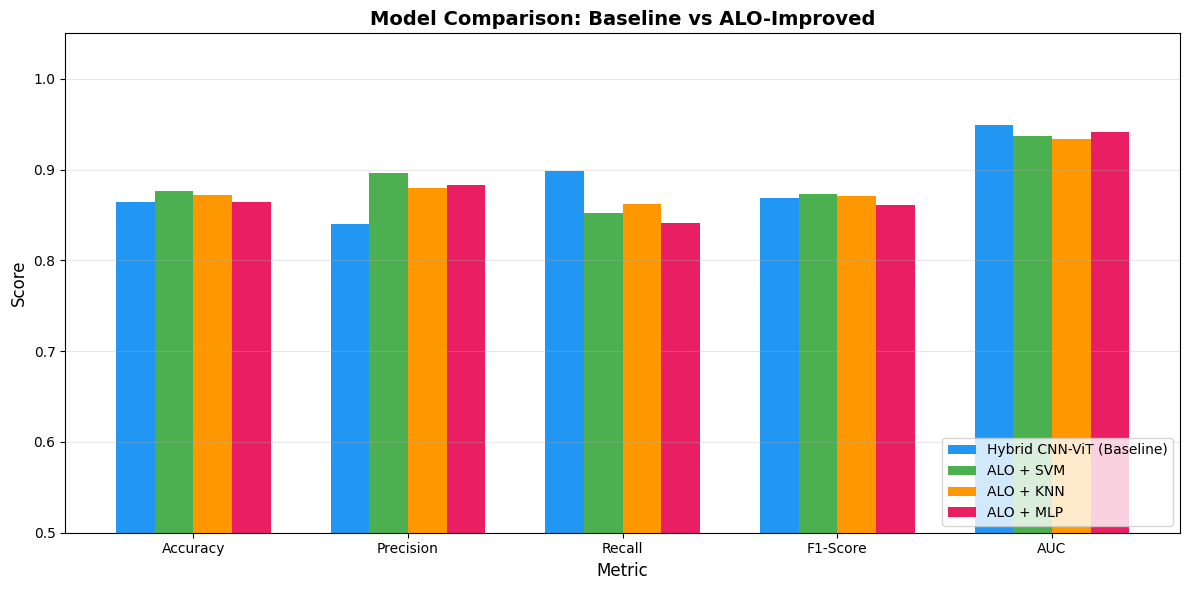

In [13]:
# =========================================================
# COMPARISON: Baseline CNN-ViT vs ALO + Classifiers
# =========================================================

comparison = {
    'Model': ['Hybrid CNN-ViT (Baseline)'],
    'Accuracy': [baseline_acc],
    'Precision': [baseline_prec],
    'Recall': [baseline_rec],
    'Specificity': [baseline_spec],
    'F1-Score': [baseline_f1],
    'AUC': [baseline_auc],
    'Kappa': [baseline_kappa]
}

for name, r in alo_results.items():
    comparison['Model'].append(f'ALO + {name}')
    comparison['Accuracy'].append(r['accuracy'])
    comparison['Precision'].append(r['precision'])
    comparison['Recall'].append(r['recall'])
    comparison['Specificity'].append(r['specificity'])
    comparison['F1-Score'].append(r['f1'])
    comparison['AUC'].append(r['auc'])
    comparison['Kappa'].append(r['kappa'])

comp_df = pd.DataFrame(comparison)

print("\n" + "="*90)
print("  FINAL COMPARISON: BASELINE vs ALO-IMPROVED")
print("="*90)

# Display with formatting
display_df = comp_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'AUC']:
    display_df[col] = display_df[col].apply(lambda x: f"{x*100:.2f}%")
display_df['Kappa'] = display_df['Kappa'].apply(lambda x: f"{float(x):.4f}")

print(display_df.to_string(index=False))
print("="*90)

# Highlight best model
best_idx = comp_df['Accuracy'].idxmax()
print(f"\nBest Model: {comp_df.loc[best_idx, 'Model']} "
      f"(Accuracy: {comp_df.loc[best_idx, 'Accuracy']*100:.2f}%)")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 6))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
x = np.arange(len(metrics_to_plot))
width = 0.18
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, model_name in enumerate(comp_df['Model']):
    values = [comp_df.loc[i, m] for m in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=model_name, color=colors[i % len(colors)])

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: Baseline vs ALO-Improved', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_plot)
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.05)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('artifacts/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# Save all artifacts
np.save('artifacts/alo_convergence_curve.npy', alo_curve)
np.save('artifacts/alo_best_mask.npy', best_mask)
np.save('artifacts/alo_best_position.npy', best_pos)
np.save('artifacts/training_history.npy', history.history)

# Save comparison
comp_df.to_csv('artifacts/comparison_summary.csv', index=False)

# Save predictions for each classifier
for name, r in alo_results.items():
    pred_df = pd.DataFrame({
        'True_Label': y_test,
        'Predicted_Label': r['preds'],
        'Prob_Healthy': r['probs'][:, 0],
        'Prob_Unhealthy': r['probs'][:, 1]
    })
    pred_df.to_csv(f'artifacts/{name.lower()}_alo_predictions.csv', index=False)

# Save baseline predictions
baseline_pred_df = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_pred_baseline,
    'Prob_Healthy': y_pred_prob[:, 0],
    'Prob_Unhealthy': y_pred_prob[:, 1]
})
baseline_pred_df.to_csv('artifacts/baseline_predictions.csv', index=False)

# Save model
model.save('artifacts/hybrid_cnn_vit_alo_final.h5')

print("All artifacts saved to artifacts/ directory!")
print(f"\nSummary:")
print(f"  - Selected features: {np.sum(best_mask)} / {len(best_mask)}")
print(f"  - Baseline accuracy: {baseline_acc*100:.2f}%")
best_alo_name = max(alo_results, key=lambda k: alo_results[k]['accuracy'])
print(f"  - Best ALO model: {best_alo_name} ({alo_results[best_alo_name]['accuracy']*100:.2f}%)")
print(f"  - Improvement: {(alo_results[best_alo_name]['accuracy'] - baseline_acc)*100:+.2f}%")

All artifacts saved to artifacts/ directory!

Summary:
  - Selected features: 128 / 256
  - Baseline accuracy: 86.40%
  - Best ALO model: SVM (87.66%)
  - Improvement: +1.26%
